# Lab3 - Pool-Based Active Learning

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki

We will explore a pool-based active learning approach by designing a simple evaluation loop and demonstrating the use of uncertainty measures within this approach.

To assess the methods, we will work with a dataset that includes pre-labeled data but will intentionally omit most labels to simulate an active learning scenario.


## 0. Import libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Dataset preparation


In [3]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml("nomao", return_X_y=False, version=1)
X = bunch.data.to_numpy(dtype=float)
y = bunch.target.astype(int).to_numpy()


### Get familiar with the dataset


In [4]:
from IPython.display import display, Markdown

display(Markdown(bunch.DESCR))

**Author**: Nomao Labs

**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Nomao)

**Please cite**: Laurent Candillier and Vincent Lemaire. Design and Analysis of the Nomao Challenge - Active Learning in the Real-World. In: Proceedings of the ALRA : Active Learning in Real-world Applications, Workshop ECML-PKDD 2012, Friday, September 28, 2012, Bristol, UK.

1. Data set title:
Nomao Data Set 


2. Abstract: 
Nomao collects data about places (name, phone, localization...) from many sources. Deduplication consists in detecting what data refer to the same place. Instances in the dataset compare 2 spots.

3. Data Set Characteristics:  

- Univariate
- Area: Computer
- Attribute Characteristics: Real
- Associated Tasks: Classification
- Missing Values?: Yes


4. Source:

(a) Original owner of database (name / phone / snail address / email address) 
Nomao / 00 33 5 62 48 33 90 / 1 avenue Jean Rieux, 31500 Toulouse / challenge '@' nomao.com 
(b) Donor of database (name / phone / snail address / email address) 
Laurent Candillier / - / 1 avenue Jean Rieux, 31500 Toulouse / laurent '@' nomao.com


5. Data Set Information:

The dataset has been enriched during the Nomao Challenge: organized along with the ALRA workshop (Active Learning in Real-world Applications): held at the ECML-PKDD 2012 conference.

5.1. Number of Instances

34,465 instances, mix of continuous and nominal, labeled by human expert.

First 29,104 instances have been labeled with "human prior".
See the corresponding article described in section "3. Past Usage" for more details.

Next 917 instances have been labeled using the active learning method called "marg".
Next 964 instances refer to the active method called "wmarg".
Next 995 instances refer to the active method called "wmarg5".
Next 1,985 instances refer to the active method called "rand" (random selection).

Last instances have been labeled during the corresponding challenge.
More details can be found in http://www.nomao.com/labs/challenge
Next 163 instances refer to the active method called "baseline".
Next 167 instances refer to the active method called "nomao".
And last 170 instances refer to the active method called "tsun".

5.2. Number of Attributes 

120 attributes: 89 continuous, 31 nominal (including the attributes 'label' and 'id'). 

The features are separated by comma.

5.3. Attribute Information: 

Missing data are allowed, represented by question marks '?'.

Labels are +1 if the concerned spots must be merged, -1 if they do not refer to the same entity.

1 id: name is composed of the names of the spots that are compared, separated by a sharp (#).   
2 clean_name_intersect_min: continuous.   
3 clean_name_intersect_max: continuous.   
4 clean_name_levenshtein_sim: continuous.   
5 clean_name_trigram_sim: continuous.   
6 clean_name_levenshtein_term: continuous.   
7 clean_name_trigram_term: continuous.   
8 clean_name_including: n,s,m.   
9 clean_name_equality: n,s,m.   
10 city_intersect_min: continuous.   
11 city_intersect_max: continuous.   
12 city_levenshtein_sim: continuous.   
13 city_trigram_sim: continuous.   
14 city_levenshtein_term: continuous.   
15 city_trigram_term: continuous.   
16 city_including: n,s,m.   
17 city_equality: n,s,m.   
18 zip_intersect_min: continuous.   
19 zip_intersect_max: continuous.   
20 zip_levenshtein_sim: continuous.   
21 zip_trigram_sim: continuous.   
22 zip_levenshtein_term: continuous.   
23 zip_trigram_term: continuous.   
24 zip_including: n,s,m.   
25 zip_equality: n,s,m.   
26 street_intersect_min: continuous.   
27 street_intersect_max: continuous.   
28 street_levenshtein_sim: continuous.   
29 street_trigram_sim: continuous.   
30 street_levenshtein_term: continuous.   
31 street_trigram_term: continuous.   
32 street_including: n,s,m.   
33 street_equality: n,s,m.   
34 website_intersect_min: continuous.   
35 website_intersect_max: continuous.   
36 website_levenshtein_sim: continuous.   
37 website_trigram_sim: continuous.   
38 website_levenshtein_term: continuous.   
39 website_trigram_term: continuous.   
40 website_including: n,s,m.   
41 website_equality: n,s,m.   
42 countryname_intersect_min: continuous.   
43 countryname_intersect_max: continuous.   
44 countryname_levenshtein_sim: continuous.   
45 countryname_trigram_sim: continuous.   
46 countryname_levenshtein_term: continuous.   
47 countryname_trigram_term: continuous.   
48 countryname_including: n,s,m.   
49 countryname_equality: n,s,m.   
50 geocoderlocalityname_intersect_min: continuous.   
51 geocoderlocalityname_intersect_max: continuous.   
52 geocoderlocalityname_levenshtein_sim: continuous.   
53 geocoderlocalityname_trigram_sim: continuous.   
54 geocoderlocalityname_levenshtein_term: continuous.   
55 geocoderlocalityname_trigram_term: continuous.   
56 geocoderlocalityname_including: n,s,m.   
57 geocoderlocalityname_equality: n,s,m.   
58 geocoderinputaddress_intersect_min: continuous.   
59 geocoderinputaddress_intersect_max: continuous.   
60 geocoderinputaddress_levenshtein_sim: continuous.   
61 geocoderinputaddress_trigram_sim: continuous.   
62 geocoderinputaddress_levenshtein_term: continuous.   
63 geocoderinputaddress_trigram_term: continuous.   
64 geocoderinputaddress_including: n,s,m.   
65 geocoderinputaddress_equality: n,s,m.   
66 geocoderoutputaddress_intersect_min: continuous.   
67 geocoderoutputaddress_intersect_max: continuous.   
68 geocoderoutputaddress_levenshtein_sim: continuous.   
69 geocoderoutputaddress_trigram_sim: continuous.   
70 geocoderoutputaddress_levenshtein_term: continuous.   
71 geocoderoutputaddress_trigram_term: continuous.   
72 geocoderoutputaddress_including: n,s,m.   
73 geocoderoutputaddress_equality: n,s,m.   
74 geocoderpostalcodenumber_intersect_min: continuous.   
75 geocoderpostalcodenumber_intersect_max: continuous.   
76 geocoderpostalcodenumber_levenshtein_sim: continuous.   
77 geocoderpostalcodenumber_trigram_sim: continuous.   
78 geocoderpostalcodenumber_levenshtein_term: continuous.   
79 geocoderpostalcodenumber_trigram_term: continuous.   
80 geocoderpostalcodenumber_including: n,s,m.   
81 geocoderpostalcodenumber_equality: n,s,m.   
82 geocodercountrynamecode_intersect_min: continuous.   
83 geocodercountrynamecode_intersect_max: continuous.   
84 geocodercountrynamecode_levenshtein_sim: continuous.   
85 geocodercountrynamecode_trigram_sim: continuous.   
86 geocodercountrynamecode_levenshtein_term: continuous.   
87 geocodercountrynamecode_trigram_term: continuous.   
88 geocodercountrynamecode_including: n,s,m.   
89 geocodercountrynamecode_equality: n,s,m.   
90 phone_diff: continuous.   
91 phone_levenshtein: continuous.   
92 phone_trigram: continuous.   
93 phone_equality: n,s,m.   
94 fax_diff: continuous.   
95 fax_levenshtein: continuous.   
96 fax_trigram: continuous.   
97 fax_equality: n,s,m.   
98 street_number_diff: continuous.   
99 street_number_levenshtein: continuous.   
100 street_number_trigram: continuous.   
101 street_number_equality: n,s,m.   
102 geocode_coordinates_long_diff: continuous.   
103 geocode_coordinates_long_levenshtein: continuous.   
104 geocode_coordinates_long_trigram: continuous.   
105 geocode_coordinates_long_equality: n,s,m.   
106 geocode_coordinates_lat_diff: continuous.   
107 geocode_coordinates_lat_levenshtein: continuous.   
108 geocode_coordinates_lat_trigram: continuous.   
109 geocode_coordinates_lat_equality: n,s,m.   
110 coordinates_long_diff: continuous.   
111 coordinates_long_levenshtein: continuous.   
112 coordinates_long_trigram: continuous.   
113 coordinates_long_equality: n,s,m.   
114 coordinates_lat_diff: continuous.   
115 coordinates_lat_levenshtein: continuous.   
116 coordinates_lat_trigram: continuous.   
117 coordinates_lat_equality: n,s,m.   
118 geocode_coordinates_diff: continuous.   
119 coordinates_diff: continuous.   
120 label: +1,-1.

Relevant Papers: Laurent Candillier and Vincent Lemaire. Design and Analysis of the Nomao Challenge - Active Learning in the Real-World. In: Proceedings of the ALRA : Active Learning in Real-world Applications, Workshop ECML-PKDD 2012, Friday, September 28, 2012, Bristol, UK.

Downloaded from openml.org.

In [5]:
bunch.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34465 entries, 0 to 34464
Columns: 118 entries, V1 to V118
dtypes: category(29), float64(89)
memory usage: 24.4 MB


In [6]:
bunch.data.describe()

,V1,V2,V3,V4,V5,V6,V9,V10,V11,V12,...,V106,V107,V109,V110,V111,V113,V114,V115,V117,V118
count,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,...,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000,34465.000000
mean,0.636477,0.494806,0.626273,0.560947,0.534202,0.506693,0.860946,0.821590,0.883386,0.854119,...,0.765575,0.628865,0.978679,0.607880,0.396168,0.982576,0.644336,0.438054,0.988839,0.979322
std,0.424382,0.380142,0.305667,0.369695,0.325744,0.372908,0.203808,0.210159,0.149473,0.181257,...,0.234591,0.346032,0.070081,0.137677,0.172149,0.064814,0.123862,0.156237,0.086640,0.084597
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,0.000000,0.008755,0.000000,0.000000,0.020058,0.000000,0.000000,0.000064,0.000077
25%,0.000000,0.000000,0.361111,0.218750,0.240000,0.139535,0.860946,0.821590,0.883386,0.854119,...,0.600000,0.294118,0.978679,0.607880,0.357143,0.982576,0.644336,0.400000,0.999992,0.979322
50%,1.000000,0.500000,0.666667,0.666667,0.473684,0.478261,0.860946,0.821590,0.883386,0.854119,...,0.700000,0.466667,0.978679,0.607880,0.396168,0.982576,0.644336,0.438054,1.000000,0.979322
75%,1.000000,1.000000,1.000000,1.000000,0.875000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.999457,0.607880,0.396168,0.999653,0.644336,0.438054,1.000000,0.999999
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Check how many null values are there in the dataset (per column and in total)


In [7]:
# write your code here

column_nans = np.isnan(X).sum(axis=0)
total_nulls = column_nans.sum()

print(f"Column Nulls: {column_nans}")
print(f"Total NaNs: {total_nulls}")




Column Nulls: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0]
Total NaNs: 0


### What is the distribution of the target variable?

The exact target distribution is rarely available in real-life scenarios. However, we can consult domain experts for insights and obtain rough estimates. At the very least, we can gain knowledge about the unique classes.


In [8]:
# write your code here
y_elements, y_counts = np.unique(y, return_counts=True)

print(f"Unique elements:")
for element, counts in zip(y_elements, y_counts):
    print(f"{element}\t{counts}")



Unique elements:
1	9844
2	24621


The dataset consists of 34465 samples and 118 features. There are 89 numerical features and 29 categorical features. The dataset does not contain any missing values. The target variable is binary (we have two classes: 1 and 2) and the classes are imbalanced.


## 2. Prepare the environment to simulate active learning

We are going to use 40% (test) of the dataset for evaluation. The remaining 60% will be used to simulate a pool-based active learning scenario.

Q: How can we assess the performance of models during a real-life active learning process?
Usually, since labeling objects is expensive, we can use a small holdout set - a portion of the already labeled data for evaluation. If we no longer need this data for evaluation, it can be used to train the final model before deployment.


In [9]:
# write your code here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)



## 3. Choose classifiers

Sample 1% of the "simulation" dataset as an initially labeled dataset part. The remaining 99% will be used as a set (pool) of unlabeled samples.

Train a classifier of your choice (would the sklearn.LogisticRegression classifier be a good choice?) on the initial dataset. Evaluate it using the BAC metric (since the problem is imbalanced) on both the test set and the dataset it was trained on.

Prepare your solution in such a way that a classifier can be easily replaced with another one (or the same one with different hyperparameters).

Use a couple of different classifiers (at least two) and compare the achieved results for all of the remaining steps.


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

scaler_test = StandardScaler()
X_test = scaler_test.fit_transform(X_test)

In [11]:
# write your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

X_init, X_sim, y_init, y_sim = train_test_split(X_train, y_train, test_size=0.99) 

classifiers = {
    "logreg": LogisticRegression(max_iter=800),
    "rf": RandomForestClassifier(n_estimators=40, warm_start=False, n_jobs=-1),
    "tree": DecisionTreeClassifier()
    }

print("Model\tBAC (X_init)\tBAC (X_test)")
for name, clf in classifiers.items():
    clf.fit(X_init, y_init)
    y_pred_init = clf.predict(X_init)
    score_init = balanced_accuracy_score(y_init, y_pred_init)
    y_pred_test = clf.predict(X_test)
    score_test = balanced_accuracy_score(y_test, y_pred_test)
    print(f"{name}\t{score_init:.4}\t{score_test:.4}" )

print("\n\n")
rfclf = RandomForestClassifier(n_estimators=200)
rfclf.fit(X_init, y_init)
print(rfclf.predict_proba(X_test)[:10])
print(y_test[:10])
test_prob = rfclf.predict_proba(X_test)[:10]

Model	BAC (X_init)	BAC (X_test)
logreg	0.9844	0.9016
rf	0.9967	0.8846
tree	1.0	0.8477



[[0.935 0.065]
 [0.    1.   ]
 [0.015 0.985]
 [0.145 0.855]
 [0.875 0.125]
 [0.37  0.63 ]
 [0.16  0.84 ]
 [0.955 0.045]
 [0.    1.   ]
 [0.255 0.745]]
[1 2 2 2 1 2 2 1 2 2]


## 4. Prepare a skeleton of the active learning loop

Until the budget is exhausted (3-5% of the train dataset), repeat the following steps:

1. Train the model on the currently labeled objects (initially this is just `X_initial` and `y_initial`). Record its performance, so we can plot it later.
2. Make predictions on the "remaining" dataset.
3. Compute informativeness value for each of the objects using a given informativeness function:

   - Entropy informativeness:
     $$ H(x) = -\sum_{i=1}^K p_i(x) \cdot log(p_i(x)) $$

   - Margin informativeness:
     (here we use `1 - ...` so that we can use the same approach that maximizes informativeness of the selected objects)
     $$ M(x) = 1 - [ max_{i=1, \ldots, K} p_i(x) - max^{[2]}_{i=1, \ldots, K} p_i(x)] $$ 
        where $max^{[2]}$ represents the second largest value
   
   - Random informativeness, which returns random values from uniform distribution [0, 1]


4. Select a sample based on informativeness (maximize informativeness), add it to the "current" dataset, and remove it from the "remaining" dataset - that way we simulate the object being labeled by an expert.


### Implement the informativeness functions


In [12]:
# write your code here


def entropy_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    M = np.zeros(predictions_probabilities.shape[0])
    mask = np.where(np.all(predictions_probabilities != 0, axis=1))
    M[mask] = np.sum(-predictions_probabilities[mask] * np.log(predictions_probabilities[mask]), axis=1)
    return M

def margin_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    return np.ones(predictions_probabilities.shape[0]) - np.sort(predictions_probabilities, axis=1)[:, -1] + np.sort(predictions_probabilities, axis=1)[:, -2]

def random_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    return np.random.uniform(0, 1, predictions_probabilities.shape[0])


### Implement the active learning loop


In [13]:
# write your code here
from tqdm import tqdm

N = 1000
metrics = [entropy_informativeness, margin_informativeness, random_informativeness]
classification_model = "tree"

def predict_model_performance(classification_model, N=N, informativeness = metrics):
    steps = np.arange(N)
    performance = np.zeros((len(metrics), N))

    for k, model in enumerate(metrics):

        classifier = classifiers[classification_model]

        X_init_working = list(np.copy(X_init))
        X_sim_working = np.copy(X_sim)
        y_init_working = list(np.copy(y_init))
        y_sim_working = np.copy(y_sim)


        for i in tqdm(range(N)):
            classifier.fit(X_init_working, y_init_working)

            performance[k, i] = balanced_accuracy_score(
                y_test, classifier.predict(X_test)
            )

            informativeness = model(classifier.predict_proba(X_sim_working))
            most_interesting_idx = np.argmax(informativeness)

            # dodajemy nową próbkę
            X_init_working.append(X_sim_working[most_interesting_idx])
            y_init_working.append(y_sim_working[most_interesting_idx])


            # usuwamy ją z puli
            mask = np.ones(len(X_sim_working), dtype=bool)
            mask[most_interesting_idx] = False
            X_sim_working = X_sim_working[mask]
            y_sim_working = y_sim_working[mask]
    return steps, performance

def display(performance, classifier_name):
    steps = np.arange(performance.shape[1])
    plt.plot(steps, performance[0], label = "entropy_informativeness")
    plt.plot(steps, performance[1], label = "margin_informativeness")
    plt.plot(steps, performance[2], label = "random_informativeness")
    plt.xlabel("steps")
    plt.ylabel("BAC score")
    plt.title(classifier_name)
    plt.legend()
    plt.show()

In [14]:
#perform the calculations

steps, performance = predict_model_performance("rf", N=1000)

100%|██████████| 1000/1000 [01:54<00:00,  8.71it/s]


### Present the results

Plot the results (BAC on the test set) for a given classifier and different informativeness functions on the same plot. Additionally, plot the reference line for the classifier trained on the whole simulation dataset.

Similarly, plot the metric values for the datasets the classifier was trained on.


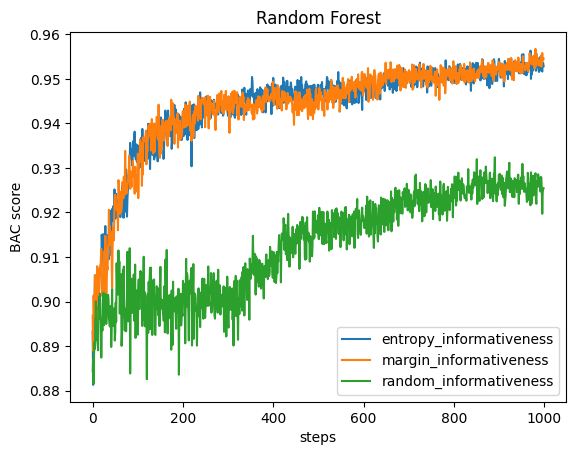

In [15]:
# write your code here
display(performance, "Random Forest")


### Try different classifiers


In [16]:
steps, performance = predict_model_performance("tree", 1500)

100%|██████████| 1500/1500 [01:00<00:00, 24.71it/s]


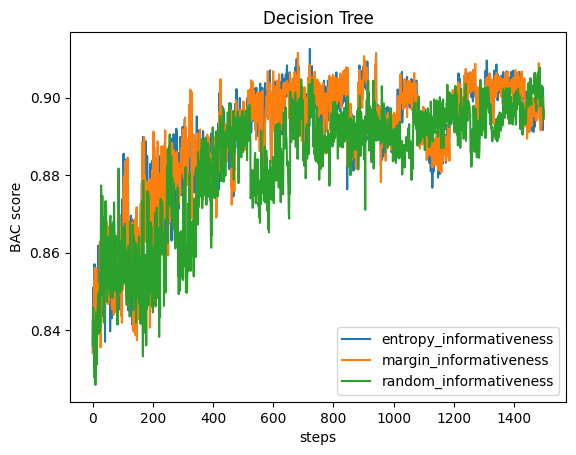

In [17]:
# write your code here

display(performance, "Decision Tree")




In [18]:
steps, performance = predict_model_performance("logreg", 1500)

100%|██████████| 1500/1500 [00:54<00:00, 27.44it/s]


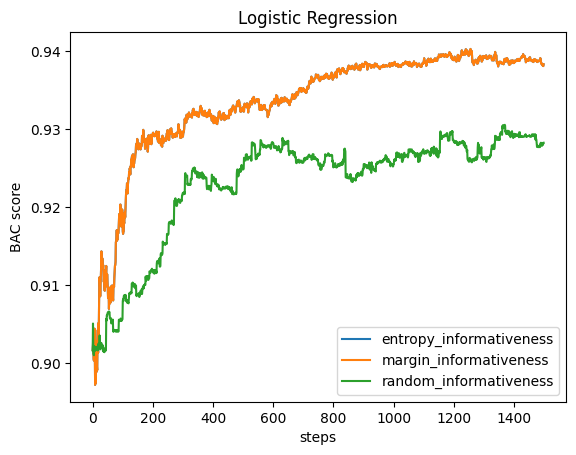

In [19]:
# write your code here

display(performance, "Logistic Regression")


## 5*. Refactor the code to a more general active learning framework

Refactor your code. Prepare an active learning framework that can be easily extended with new classifiers, informativeness functions, and selection strategies. It should be possible to run an experiment with: 

1. Different strategies for selecting the initial dataset. By default, it should be random sampling as in the approach above. It should be possible to define the size of the initial dataset.
2. Different classifiers or hyperparameters for the classifiers.
3. Different informativeness functions.
4. Different selection strategies for choosing the next object (or several objects) to label. By default, it should be the maximum informativeness value. The number of objects to label in one iteration should be given as a parameter - default 1.
5. Different strategies for retraining the model. By default, it should retrain the model from scratch. As an alternative, it should be possible to fine-tune the model.
6. Different evaluation metrics.  

Try to specify the default parameters so that we can run an experiment passing just the data.


In [20]:
# write your code here

#strategie wyboru próbek
def select_top_k(informativeness, k=1):
    idx = np.argsort(-informativeness)[:k]
    return idx

def select_random_k(informativeness, k=1):
    n = len(informativeness)
    idx = np.random.choice(n, size=k, replace=False)
    return idx

def active_learning_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    # 1. strategia inicjalizacji
    init_strategy=train_test_split,
    init_size=0.01,
    # 2. klasyfikator
    classifier_factory=lambda: RandomForestClassifier(
        n_estimators=40, n_jobs=-1
    ),
    # 3. funkcje informatywności
    informativeness_functions=None,
    # 4. strategia wyboru próbek
    selection_strategy=select_top_k,
    batch_size=2,
    # 5. strategia retrainingu
    retrain_mode="from_scratch",  # albo "fine_tune"
    # 6. metryki
    metrics=None,
    # inne
    steps=100,
    random_state=42,
):
    if informativeness_functions is None:
        informativeness_functions = {
            "entropy": entropy_informativeness,
            "margin": margin_informativeness,
            "random": random_informativeness,
        }

    if metrics is None:
        metrics = {
            "BAC": balanced_accuracy_score
        }

    # inicjalizacja
    X_init, X_pool, y_init, y_pool = init_strategy(
        X_train, y_train, train_size=init_size, random_state=random_state
    )

    results = {name: {m_name: [] for m_name in metrics.keys()}
               for name in informativeness_functions.keys()}

    for info_name, info_func in informativeness_functions.items():

        # osobny klasyfikator dla każdej strategii
        clf = classifier_factory()

        X_labeled = np.copy(X_init)
        y_labeled = np.copy(y_init)
        X_unlabeled = np.copy(X_pool)
        y_unlabeled = np.copy(y_pool)

        for _ in tqdm(range(steps)):

            # 5. retraining
            if retrain_mode == "from_scratch":
                clf = classifier_factory()
                clf.fit(X_labeled, y_labeled)
            elif retrain_mode == "fine_tune":
                clf.fit(X_labeled, y_labeled)
            else:
                raise ValueError("Unknown retrain_mode")

            # 6. ewaluacja
            y_pred_test = clf.predict(X_test)
            for m_name, m_func in metrics.items():
                results[info_name][m_name].append(m_func(y_test, y_pred_test))

            # koniec jeśli nie ma już próbek
            if len(X_unlabeled) == 0:
                break

            # 3. informativeness
            proba = clf.predict_proba(X_unlabeled)
            info_values = info_func(proba)

            # 4. wybór próbek
            idx = selection_strategy(info_values, k=batch_size)

            # aktualizacja zbiorów
            X_labeled = np.vstack([X_labeled, X_unlabeled[idx]])
            y_labeled = np.concatenate([y_labeled, y_unlabeled[idx]])

            mask = np.ones(len(X_unlabeled), dtype=bool)
            mask[idx] = False
            X_unlabeled = X_unlabeled[mask]
            y_unlabeled = y_unlabeled[mask]

    return results

def plot_results(results):
    steps = range(len(next(iter(results.values()))["BAC"]))
    for info_name, metrics_dict in results.items():
        plt.plot(steps, metrics_dict["BAC"], label=info_name)
    plt.xlabel("steps")
    plt.ylabel("BAC")
    plt.legend()
    plt.show()



### Run the previous experiments using the new framework

Run the same experiment as in the previous step using the new framework. Compare the results to be sure that the refactoring was successful.

In [ ]:
# write your code here

results = active_learning_experiment(
    X_train, y_train, X_test, y_test,
    steps=500
)




  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:57<00:00,  8.68it/s]


{'entropy': {'BAC': [0.8988131357892988, 0.8873564567728214, 0.9011343853650033, 0.8953972102916143, 0.8887999234406714, 0.8939066076352309, 0.8985439818993652, 0.9059312409313822, 0.8955897633347816, 0.9097634370197931, 0.9044818838867654, 0.9112346559253182, 0.9092758850855478, 0.8989610179795837, 0.90708977684113, 0.9173970409497696, 0.9131603550241657, 0.9098896519651425, 0.9191976668503063, 0.9071023230841556, 0.9092481328478729, 0.912152931929846, 0.9087854787837062, 0.9188045815091006, 0.9107003442600861, 0.9047265161641669, 0.911200442437357, 0.9190644197811515, 0.9161461273250868, 0.9145950769476524, 0.9128607891449334, 0.9141166460153172, 0.9189530345729048, 0.9291586053487269, 0.9211064473339468, 0.9246326162928392, 0.9269339112441661, 0.9271525039044505, 0.922366676576512, 0.9258966470340668, 0.9247766969844617, 0.9305617735358762, 0.9281783636185628, 0.9297723722283215, 0.930958089502225, 0.9284437160098339, 0.9263619608498573, 0.9305100705591884, 0.9303633301159421, 0.933

TypeError: 'dict' object is not callable

In [ ]:
print(results)

print(results.keys())
for name in results.keys():
    print(results[name].keys())

{'entropy': {'BAC': [0.8988131357892988, 0.8873564567728214, 0.9011343853650033, 0.8953972102916143, 0.8887999234406714, 0.8939066076352309, 0.8985439818993652, 0.9059312409313822, 0.8955897633347816, 0.9097634370197931, 0.9044818838867654, 0.9112346559253182, 0.9092758850855478, 0.8989610179795837, 0.90708977684113, 0.9173970409497696, 0.9131603550241657, 0.9098896519651425, 0.9191976668503063, 0.9071023230841556, 0.9092481328478729, 0.912152931929846, 0.9087854787837062, 0.9188045815091006, 0.9107003442600861, 0.9047265161641669, 0.911200442437357, 0.9190644197811515, 0.9161461273250868, 0.9145950769476524, 0.9128607891449334, 0.9141166460153172, 0.9189530345729048, 0.9291586053487269, 0.9211064473339468, 0.9246326162928392, 0.9269339112441661, 0.9271525039044505, 0.922366676576512, 0.9258966470340668, 0.9247766969844617, 0.9305617735358762, 0.9281783636185628, 0.9297723722283215, 0.930958089502225, 0.9284437160098339, 0.9263619608498573, 0.9305100705591884, 0.9303633301159421, 0.933